# 01 — Data Exploration

Inspect FineBadminton and ShuttleSet data:
- Frame quality and resolution
- Annotation structure and strategy distribution
- Skeleton extraction quality (YOLOv8-Pose on sample frames)
- Graph visualization (dual-player skeleton graph)

In [19]:
!pip install torch scikit-learn matplotlib inline ultralytics groundingdino

ERROR: Could not find a version that satisfies the requirement groundingdino (from versions: none)
ERROR: No matching distribution found for groundingdino


In [ ]:
import sys
sys.path.insert(0, '..')

import json
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from src.config import *

## 1. FineBadminton Annotations

In [3]:
# Load and inspect FineBadminton annotations
print(f"Annotations path: {FB_ANNOTATIONS}")
print(f"Exists: {FB_ANNOTATIONS.exists()}")

if FB_ANNOTATIONS.exists():
    with open(FB_ANNOTATIONS) as f:
        fb_annotations = json.load(f)
    
    print(f"\nType: {type(fb_annotations)}")
    if isinstance(fb_annotations, list):
        print(f"Number of entries: {len(fb_annotations)}")
        print(f"\nFirst entry keys: {fb_annotations[0].keys() if fb_annotations else 'empty'}")
        print(f"\nFirst entry:")
        print(json.dumps(fb_annotations[0], indent=2, ensure_ascii=False)[:2000])
    elif isinstance(fb_annotations, dict):
        print(f"Top-level keys: {list(fb_annotations.keys())}")
        for k, v in fb_annotations.items():
            print(f"  {k}: {type(v).__name__}, len={len(v) if hasattr(v, '__len__') else 'N/A'}")

Annotations path: /Users/yuen@backbase.com/Documents/Baddiev2/Datasets/FineBadminton-dataset/dataset/transformed_combined_rounds_output_en_evals_translated.json
Exists: True

Type: <class 'list'>
Number of entries: 40

First entry keys: dict_keys(['video', 'resolution', 'fps', 'duration_frames', 'start_frame', 'end_frame', 'hitting', 'playerList', 'QA', 'evaluations', 'video_name', 'has_optimized', 'evaluations_new', 'has_summarized', 'has_correct'])

First entry:
{
  "video": "0011_001.mp4",
  "resolution": {
    "width": 1280,
    "height": 720
  },
  "fps": 25.0,
  "duration_frames": 327,
  "start_frame": 16362,
  "end_frame": 16688,
  "hitting": [
    {
      "start_frame": 16362,
      "end_frame": 16378,
      "player": "Kento MOMOTA",
      "hit_type": "serve",
      "subtype": [
        "short serve"
      ],
      "quality": "4",
      "comment": "top player a backhand short serve",
      "hit_frame": 16363,
      "get_point": [],
      "ball_area": "mid front court",
      "h

## 2. FineBadminton Frame Samples

Total frames: 10620


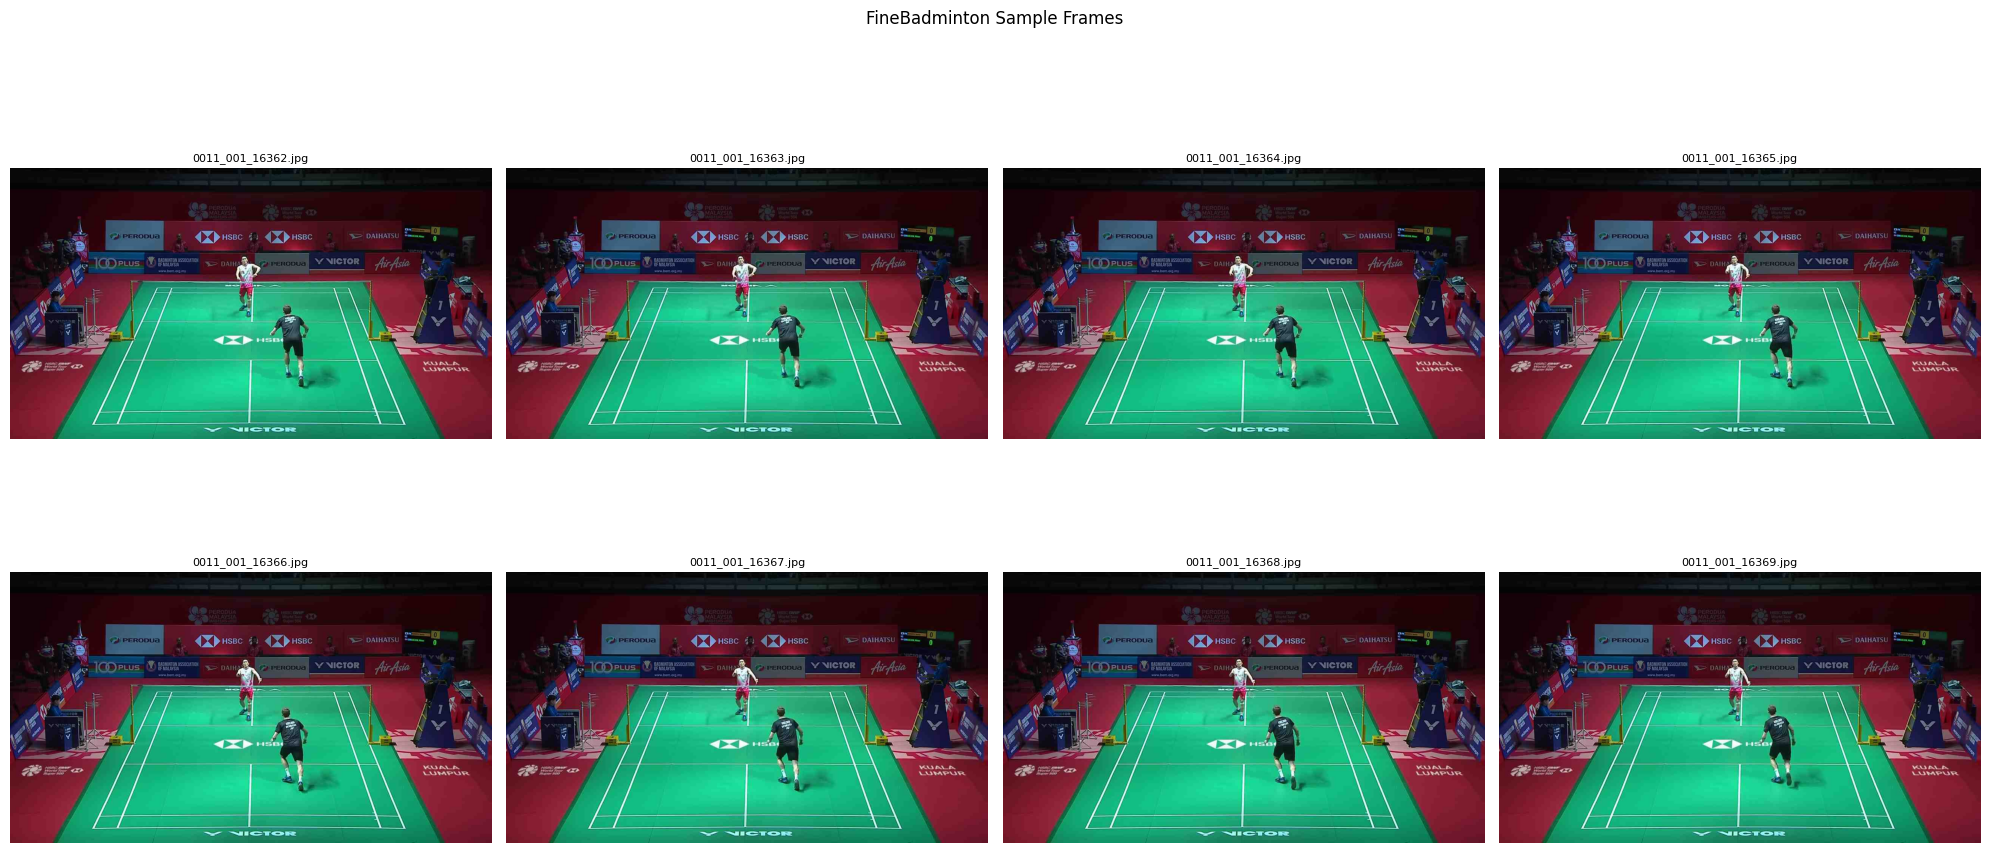

In [10]:
# Show sample frames from FineBadminton
import cv2

frame_files = sorted(FB_FRAMES.glob('*.jpg'))[:8]
print(f"Total frames: {len(list(FB_FRAMES.glob('*.jpg')))}")

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
for ax, fpath in zip(axes.flat, frame_files):
    img = cv2.imread(str(fpath))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    ax.imshow(img)
    ax.set_title(fpath.name, fontsize=8)
    ax.axis('off')
plt.suptitle('FineBadminton Sample Frames')
plt.tight_layout()
plt.show()

## 3. Grounding Dino Experiment 


In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import ultralytics
from ultralytics import YOLO

In [ ]:
# Load Grounding DINO model (change checkpoint path as needed)
dino_model = load_model(
    config_path="GroundingDINO/config/GroundingDINO_SwinT_OGC.py",
    checkpoint_path="GroundingDINO/weights/groundingdino_swinb_coco.pth"
)

# Read a sample frame
frame = cv2.imread(str(frame_files[0]))
frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

# Run detection for "player" or "person"
boxes, scores, labels = predict(
    model=dino_model,
    image=frame_rgb,
    caption="person",
    box_threshold=0.3,
    text_threshold=0.25
)

# Visualize detected players
fig, ax = plt.subplots(figsize=(12, 8))
ax.imshow(frame_rgb)
for box, score, label in zip(boxes, scores, labels):
    x0, y0, x1, y1 = box.astype(int)
    ax.add_patch(
        plt.Rectangle((x0, y0), x1-x0, y1-y0, fill=False, edgecolor='lime', linewidth=2)
    )
    ax.text(x0, y0-10, f"{label}: {score:.2f}", color='lime', fontsize=12)
ax.set_title("Grounding DINO — Player Detection")
ax.axis('off')
plt.show()

## 4. Test Pose Extraction on Sample Frames

Keypoints shape: (2, 17, 2)


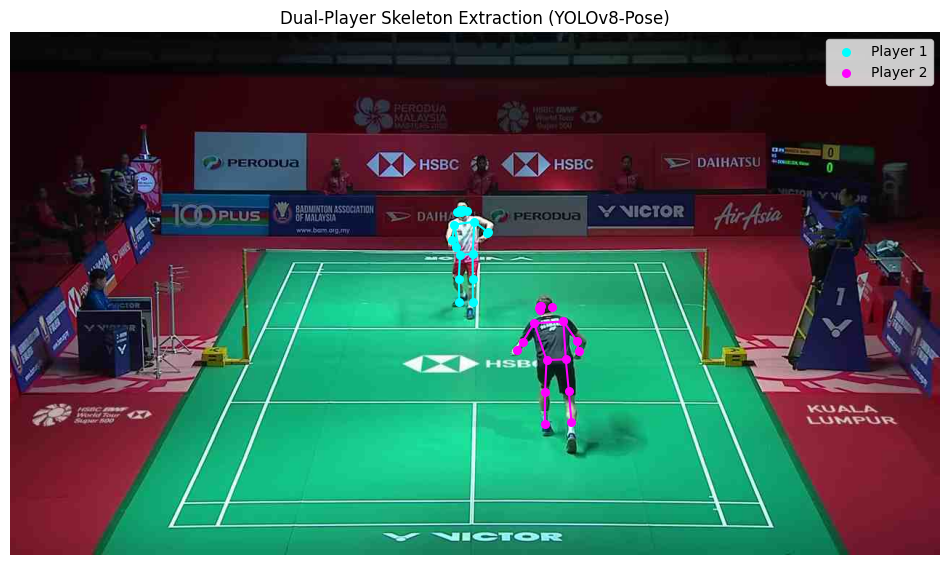

In [22]:
# Test YOLOv8-Pose directly in notebook (standalone, no src imports)

# Standard COCO skeleton connections (for visualization only)
COCO_SKELETON = [
    (5, 7), (7, 9),      # left arm
    (6, 8), (8, 10),     # right arm
    (5, 6),              # shoulders
    (5, 11), (6, 12),    # torso
    (11, 13), (13, 15),  # left leg
    (12, 14), (14, 16),  # right leg
    (11, 12)             # hips
]

# Load YOLOv8 Pose model (you can change to yolov8s-pose.pt if needed)
model = YOLO("yolov8n-pose.pt")

# Read a sample frame
sample_frame = cv2.imread(str(frame_files[0]))

if sample_frame is None:
    raise ValueError("Failed to load frame")

# Run pose inference
results = model(sample_frame, verbose=False)

kpts = None
if results and len(results) > 0:
    result = results[0]
    if result.keypoints is not None and len(result.keypoints) >= 2:
        # (N, 17, 2)
        all_kpts = result.keypoints.xy.cpu().numpy()
        confs = result.keypoints.conf.cpu().numpy()

        # Select top-2 players by confidence (good for badminton)
        mean_confs = confs.mean(axis=1)
        top2_idx = np.argsort(mean_confs)[-2:]
        kpts = all_kpts[top2_idx]

        # Sort left player = index 0 (court consistency)
        center_x = kpts[:, :, 0].mean(axis=1)
        kpts = kpts[np.argsort(center_x)]

# Visualize
if kpts is not None:
    print(f"Keypoints shape: {kpts.shape}")  # expect (2, 17, 2)

    fig, ax = plt.subplots(1, 1, figsize=(12, 8))
    img_rgb = cv2.cvtColor(sample_frame, cv2.COLOR_BGR2RGB)
    ax.imshow(img_rgb)

    colors = ['cyan', 'magenta']
    num_players = min(2, len(kpts))

    for p in range(num_players):
        ax.scatter(
            kpts[p, :, 0],
            kpts[p, :, 1],
            c=colors[p],
            s=30,
            label=f'Player {p+1}'
        )

        for (i, j) in COCO_SKELETON:
            ax.plot(
                [kpts[p, i, 0], kpts[p, j, 0]],
                [kpts[p, i, 1], kpts[p, j, 1]],
                c=colors[p],
                linewidth=1.5
            )

    ax.legend()
    ax.set_title('Dual-Player Skeleton Extraction (YOLOv8-Pose)')
    ax.axis('off')
    plt.show()
else:
    print("Failed to detect 2 players in frame")

## 4. Graph Structure Visualization

Adjacency shape: torch.Size([3, 34, 34])


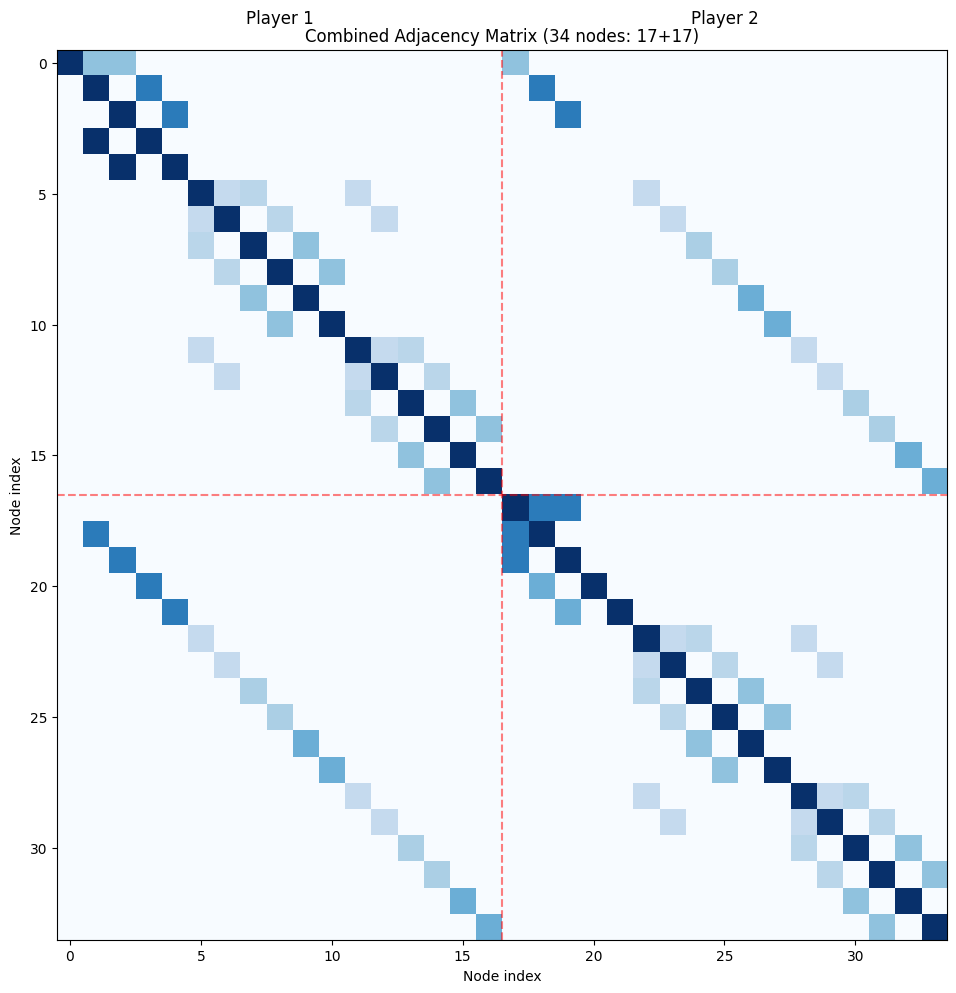

In [25]:
from src.data.graph_builder import GraphBuilder

builder = GraphBuilder(use_inter_player=True)
adjacency = builder.build_adjacency()
print(f"Adjacency shape: {adjacency.shape}")  # (3, 34, 34)

# Visualize combined adjacency
A_combined = adjacency.sum(dim=0).numpy()
fig, ax = plt.subplots(figsize=(10, 10))
ax.imshow(A_combined, cmap='Blues')
ax.set_xlabel('Node index')
ax.set_ylabel('Node index')
ax.set_title('Combined Adjacency Matrix (34 nodes: 17+17)')
ax.axhline(y=16.5, color='red', linestyle='--', alpha=0.5)
ax.axvline(x=16.5, color='red', linestyle='--', alpha=0.5)
ax.text(8, -1.5, 'Player 1', ha='center', fontsize=12)
ax.text(25, -1.5, 'Player 2', ha='center', fontsize=12)
plt.tight_layout()
plt.show()

## 5. ShuttleSet Extraction Summary

In [24]:
# Check ShuttleSet extraction pipeline outputs
outputs_dir = DATA_ROOT / 'outputs'
json_files = sorted(outputs_dir.glob('*.json'))
json_files = [f for f in json_files if f.name != 'pipeline_summary.json']
print(f"Processed matches: {len(json_files)}")

# Load summary if available
summary_path = outputs_dir / 'pipeline_summary.json'
if summary_path.exists():
    with open(summary_path) as f:
        summary = json.load(f)
    print(f"Total strokes: {summary.get('total_strokes', 'N/A')}")
    print(f"Shot types: {len(summary.get('shot_distribution', {}))}")

Processed matches: 25
